# 🎥 Gemastik 2026: 5-Fold Stratified GroupKFold Video ViT Classifier
### ⚡ Optimized for NVIDIA L4 GPU (24GB VRAM) in Google Colab
### Pretrained Backbone: `dima806/deepfake_vs_real_image_detection` (Vision Transformer - ViT)

This notebook fine-tunes the Vision Transformer (ViT) model **`dima806/deepfake_vs_real_image_detection`** using **5-Fold Stratified GroupKFold Cross-Validation** on the Indonesian video dataset (`Real/train.zip` and `AI/trainAI.zip`).

### 🚀 NVIDIA L4 GPU Optimizations:
1. **Batch Size 32:** Efficiently utilizes the 24 GB Ada Lovelace VRAM.
2. **Automatic Mixed Precision (AMP):** Fast FP16/BF16 tensor core acceleration (`torch.cuda.amp.autocast`).
3. **DataLoader Optimizations:** `num_workers=4`, `pin_memory=True`, `persistent_workers=True` for high throughput.
4. **VRAM Memory Management:** Explicit `torch.cuda.empty_cache()` cleanup between folds.
5. **Isolated Revision 1 Output Path:** Checkpoints saved to `/content/drive/MyDrive/Gemastik26/models/revision1/`.

## 1. Setup Environment & L4 GPU Hardware Check

In [11]:
# Install required libraries
!pip install -q transformers timm albumentations opencv-python-headless scikit-learn matplotlib seaborn tqdm pandas pillow

import os
import glob
import shutil
import random
import zipfile
import subprocess
import datetime
import json
from pathlib import Path
import pandas as pd
import numpy as np
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support
from transformers import AutoImageProcessor, AutoModelForImageClassification

# Hardware Check
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"⚡ PyTorch running on device: {device}")
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    vram_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"🎮 Detected GPU: {gpu_name} ({vram_gb:.2f} GB VRAM)")
    if "L4" in gpu_name:
        print("🚀 NVIDIA L4 GPU detected! High-throughput batching and AMP FP16 active.")

# Optional Colab Mount
try:
    from google.colab import drive
    drive.mount("/content/drive")
except Exception:
    print("ℹ️ Local environment detected.")

⚡ PyTorch running on device: cuda
🎮 Detected GPU: NVIDIA L4 (23.66 GB VRAM)
🚀 NVIDIA L4 GPU detected! High-throughput batching and AMP FP16 active.
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Model Backbone & Directory Setup

In [12]:
# Candidate paths to search for hyperparameter profile 'video_colab_L4.json'
json_name = "video_colab_L4.json"
search_paths = [
    os.path.join("notebook/revision1/hyperparameter", json_name),
    os.path.join("hyperparameter", json_name),
    os.path.join("/content/notebook/revision1/hyperparameter", json_name),
    os.path.join("/content/mancing-tipu/notebook/revision1/hyperparameter", json_name),
    os.path.join("/content/drive/MyDrive/Gemastik26/hyperparameter", json_name)
]

default_hp = {
  "modality": "video",
  "gpu_profile": "video_colab_L4",
  "gpu_name": "NVIDIA L4",
  "vram_gb": 24,
  "hf_model_id": "dima806/deepfake_vs_real_image_detection",
  "batch_size": 32,
  "epochs": 10,
  "learning_rate": 0.0001,
  "weight_decay": 0.01,
  "image_size": [
    224,
    224
  ],
  "target_fps": 1.0,
  "max_frames_per_video": 30,
  "num_workers": 4,
  "pin_memory": True,
  "persistent_workers": True,
  "use_amp_fp16": True,
  "early_stopping_patience": 3,
  "model_save_dir": "/content/drive/MyDrive/Gemastik26/models/revision1",
  "kfold_splits_file": "/content/drive/MyDrive/Gemastik26/kfold_splits.json",
  "scheduler_type": "ReduceLROnPlateau",
  "reduce_lr_factor": 0.5,
  "reduce_lr_patience": 2,
  "min_lr": 1e-06
}

CONFIG_PATH = None
for p in search_paths:
    if os.path.exists(p):
        CONFIG_PATH = p
        break

if CONFIG_PATH:
    with open(CONFIG_PATH, "r", encoding="utf-8") as f:
        hp_cfg = json.load(f)
    print(f"⚙️ Loaded Hyperparameter Profile from '{CONFIG_PATH}': {hp_cfg.get('gpu_profile', json_name)}")
else:
    hp_cfg = default_hp
    # Auto-save to local hyperparameter directory & Drive for future runs
    os.makedirs("hyperparameter", exist_ok=True)
    local_save = os.path.join("hyperparameter", json_name)
    with open(local_save, "w", encoding="utf-8") as f:
        json.dump(hp_cfg, f, indent=2)
    drive_dir = "/content/drive/MyDrive/Gemastik26/hyperparameter"
    if os.path.exists("/content/drive/MyDrive"):
        os.makedirs(drive_dir, exist_ok=True)
        with open(os.path.join(drive_dir, json_name), "w", encoding="utf-8") as f:
            json.dump(hp_cfg, f, indent=2)
    print(f"⚙️ Embedded Hyperparameter Profile Initialized & Saved to '{local_save}'")
HF_MODEL_ID = hp_cfg.get("hf_model_id", "dima806/deepfake_vs_real_image_detection")
processor = AutoImageProcessor.from_pretrained(HF_MODEL_ID)
print(f"Loaded AutoImageProcessor for '{HF_MODEL_ID}'")

BATCH_SIZE = hp_cfg.get("batch_size", 32)
EPOCHS = hp_cfg.get("epochs", 10)
LEARNING_RATE = hp_cfg.get("learning_rate", 1e-4)
WEIGHT_DECAY = hp_cfg.get("weight_decay", 1e-2)
IMAGE_SIZE = tuple(hp_cfg.get("image_size", [224, 224]))
TARGET_FPS = hp_cfg.get("target_fps", 1.0)
MAX_FRAMES = hp_cfg.get("max_frames_per_video", 30)
NUM_WORKERS = hp_cfg.get("num_workers", 4 if torch.cuda.is_available() else 2)
PIN_MEMORY = hp_cfg.get("pin_memory", True)
PERSISTENT_WORKERS = hp_cfg.get("persistent_workers", True)
PATIENCE = hp_cfg.get("early_stopping_patience", 3)
SCHEDULER_TYPE = hp_cfg.get("scheduler_type", "ReduceLROnPlateau")
REDUCE_LR_FACTOR = hp_cfg.get("reduce_lr_factor", 0.5)
REDUCE_LR_PATIENCE = hp_cfg.get("reduce_lr_patience", 2)
MIN_LR = hp_cfg.get("min_lr", 1e-6)
MODEL_SAVE_DIR = hp_cfg.get("model_save_dir", "/content/drive/MyDrive/Gemastik26/models/revision1")
KFOLD_SPLIT_FILE = hp_cfg.get("kfold_splits_file", "/content/drive/MyDrive/Gemastik26/kfold_splits.json")

# Dataset Directory Paths
DRIVE_DATASET_DIR = "/content/drive/MyDrive/Gemastik26/Dataset Indonesia"
LOCAL_RAW_DIR = "/content/dataset_raw"
LOCAL_FRAMES_DIR = "/content/dataset_frames"
CLASSES = ["Real", "AI"]
N_SPLITS = 5

ZIP_PATHS = {
    "Real": os.path.join(DRIVE_DATASET_DIR, "Real", "train.zip"),
    "AI": os.path.join(DRIVE_DATASET_DIR, "AI", "trainAI.zip")
}

os.makedirs(LOCAL_RAW_DIR, exist_ok=True)
os.makedirs(LOCAL_FRAMES_DIR, exist_ok=True)
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)

print(f"⚙️ ACTIVE VIDEO HYPERPARAMETERS:")
print(f"   Backbone: {HF_MODEL_ID} | Batch Size: {BATCH_SIZE} | Learning Rate: {LEARNING_RATE} | Epochs: {EPOCHS}")
print(f"   Workers: {NUM_WORKERS} | Image Size: {IMAGE_SIZE} | Scheduler: {SCHEDULER_TYPE} (factor={REDUCE_LR_FACTOR}, patience={REDUCE_LR_PATIENCE})")
print(f"   Model Save Path: {MODEL_SAVE_DIR}")


⚙️ Loaded Hyperparameter Profile from '/content/drive/MyDrive/Gemastik26/hyperparameter/video_colab_L4.json': video_colab_L4
Loaded AutoImageProcessor for 'dima806/deepfake_vs_real_image_detection'
⚙️ ACTIVE VIDEO HYPERPARAMETERS:
   Backbone: dima806/deepfake_vs_real_image_detection | Batch Size: 32 | Learning Rate: 0.0001 | Epochs: 10
   Workers: 4 | Image Size: (224, 224) | Scheduler: ReduceLROnPlateau (factor=0.5, patience=2)
   Model Save Path: /content/drive/MyDrive/Gemastik26/models/revision1


## 3. Unzip Video Archives & Frame Extraction (1 FPS)

In [13]:
def unzip_file(zip_path, extract_to):
    if not os.path.exists(zip_path):
        print(f"⚠️ Warning: Zip file not found at {zip_path}")
        return False
    print(f"📦 Unzipping {zip_path} -> {extract_to} ...")
    os.makedirs(extract_to, exist_ok=True)
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_to)
    print(f"✅ Unzipped successfully to {extract_to}")
    return True

for cls in CLASSES:
    extract_target = os.path.join(LOCAL_RAW_DIR, cls)
    zip_p = ZIP_PATHS.get(cls, "")
    if os.path.exists(extract_target) and len(os.listdir(extract_target)) > 0:
        print(f"⏭️ Target directory '{extract_target}' already exists. Skipping unzip.")
    else:
        unzip_file(zip_p, extract_target)

def extract_frames(video_path, output_dir, target_fps=1.0, max_frames=30):
    os.makedirs(output_dir, exist_ok=True)
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        return 0

    video_fps = cap.get(cv2.CAP_PROP_FPS)
    if video_fps <= 0 or np.isnan(video_fps):
        video_fps = 30.0

    frame_interval = max(1, int(round(video_fps / target_fps)))
    count = 0
    saved_count = 0
    video_name = Path(video_path).stem

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        if count % frame_interval == 0:
            frame_name = f"{video_name}_frame_{saved_count:04d}.jpg"
            frame_path = os.path.join(output_dir, frame_name)
            cv2.imwrite(frame_path, frame)
            saved_count += 1
            if saved_count >= max_frames:
                break
        count += 1

    cap.release()
    return saved_count

for cls in CLASSES:
    cls_raw_dir = os.path.join(LOCAL_RAW_DIR, cls)
    cls_frames_dir = os.path.join(LOCAL_FRAMES_DIR, cls)
    video_extensions = ("*.mp4", "*.avi", "*.mov", "*.mkv", "*.MP4", "*.AVI", "*.MOV", "*.MKV")
    video_files = []
    for ext in video_extensions:
        video_files.extend(glob.glob(os.path.join(cls_raw_dir, "**", ext), recursive=True))
    
    print(f"🎥 Extracting 1 FPS frames for {len(video_files)} {cls} videos ...")
    for vid in tqdm(video_files, desc=f"Frames [{cls}]"):
        v_stem = Path(vid).stem
        out_v_dir = os.path.join(cls_frames_dir, v_stem)
        if os.path.exists(out_v_dir) and len(os.listdir(out_v_dir)) > 0:
            continue
        extract_frames(vid, out_v_dir, target_fps=1.0, max_frames=30)


def extract_frames_ffmpeg(video_path, output_dir, target_fps=1.0, max_frames=30):
    """ffmpeg fallback for videos that OpenCV cannot decode (VP9/AV1/H.265 etc.)."""
    os.makedirs(output_dir, exist_ok=True)
    video_name = Path(video_path).stem
    pattern = os.path.join(output_dir, f"{video_name}_frame_%04d.jpg")
    cmd = [
        "ffmpeg", "-y", "-i", video_path,
        "-vf", f"fps={target_fps}", "-frames:v", str(max_frames),
        pattern
    ]
    subprocess.run(cmd, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    return len(glob.glob(os.path.join(output_dir, "*.jpg")))

print("✅ Frame extraction complete!")


⏭️ Target directory '/content/dataset_raw/Real' already exists. Skipping unzip.
⏭️ Target directory '/content/dataset_raw/AI' already exists. Skipping unzip.
🎥 Extracting 1 FPS frames for 654 Real videos ...


Frames [Real]:   0%|          | 0/654 [00:00<?, ?it/s]

Frames [Real]: 100%|██████████| 654/654 [00:00<00:00, 23697.66it/s]


🎥 Extracting 1 FPS frames for 413 AI videos ...


Frames [AI]: 100%|██████████| 413/413 [00:00<00:00, 862.62it/s]

✅ Frame extraction complete!


## 4. Load 5-Fold Stratified GroupKFold Split (`kfold_splits.json`)

In [14]:
all_video_samples = []
for label_idx, cls in enumerate(CLASSES):
    cls_dir = os.path.join(LOCAL_FRAMES_DIR, cls)
    if not os.path.exists(cls_dir):
        continue
    v_folders = [os.path.join(cls_dir, d) for d in os.listdir(cls_dir) if os.path.isdir(os.path.join(cls_dir, d))]
    for vf in v_folders:
        frames = glob.glob(os.path.join(vf, "*.jpg"))
        if frames:
            all_video_samples.append((vf, frames, label_idx, Path(vf).name))

# 🛡️ STRICT 5-FOLD SPLIT LOADING (Must be generated by generate_kfold_split.ipynb)
if os.path.exists(KFOLD_SPLIT_FILE):
    with open(KFOLD_SPLIT_FILE, "r", encoding="utf-8") as f:
        kfold_splits = json.load(f)
    print(f"✅ LOADED 5-FOLD SPLIT DICTIONARY FROM DRIVE:")
    print(f"➡️ {KFOLD_SPLIT_FILE}")
else:
    raise FileNotFoundError(
        f"❌ ERROR: 5-Fold split file not found at: {KFOLD_SPLIT_FILE}\n"
        f"Please execute 'generate_kfold_split.ipynb' first to generate and export kfold_splits.json to Drive!"
    )

print(f"📊 Active Folds Loaded: {list(kfold_splits.keys())}")
for f_name, f_data in kfold_splits.items():
    print(f"   - {f_name}: {len(f_data['train_stems'])} Train Stems | {len(f_data['val_stems'])} Val Stems")


✅ LOADED 5-FOLD SPLIT DICTIONARY FROM DRIVE:
➡️ /content/drive/MyDrive/Gemastik26/kfold_splits.json
📊 Active Folds Loaded: ['fold_1', 'fold_2', 'fold_3', 'fold_4', 'fold_5']
   - fold_1: 853 Train Stems | 214 Val Stems
   - fold_2: 854 Train Stems | 213 Val Stems
   - fold_3: 853 Train Stems | 214 Val Stems
   - fold_4: 854 Train Stems | 213 Val Stems
   - fold_5: 854 Train Stems | 213 Val Stems


## 5. PyTorch Dataset & L4-Optimized Transforms

In [15]:
class VideoFrameDataset(Dataset):
    def __init__(self, samples, transform=None):
        self.samples = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label

mean = processor.image_mean if hasattr(processor, 'image_mean') and processor.image_mean is not None else [0.485, 0.456, 0.406]
std = processor.image_std if hasattr(processor, 'image_std') and processor.image_std is not None else [0.229, 0.224, 0.225]

# 🟢 Section 2B.2 Train-Set-Only Video Augmentation Pipeline
aug_train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

# 🔴 Validation & Test Set (Strictly Non-Augmented)
val_transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

print("✅ Loaded Section 2B.2 Train-Only Video Augmentations:")
print("   - RandomResizedCrop(scale=[0.8, 1.0]) | RandomHorizontalFlip(p=0.5)")
print("   - RandomRotation(degrees=15) | ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2)")


✅ Loaded Section 2B.2 Train-Only Video Augmentations:
   - RandomResizedCrop(scale=[0.8, 1.0]) | RandomHorizontalFlip(p=0.5)
   - RandomRotation(degrees=15) | ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2)


## 6. L4-Optimized 5-Fold Training Pipeline (`train_vit_kfold_pipeline`)

In [16]:

def evaluate_video_level(eval_model, val_vids, batch_size=BATCH_SIZE):
    """VIDEO-LEVEL OOF evaluation: average frame softmax probs per video, vote once per video."""
    targets_list, preds_list, video_probs_list = [], [], []
    failed_count = 0
    with torch.no_grad():
        for v_folder, frame_paths, label, v_name in tqdm(val_vids, desc="[Video-Level Eval]"):
            frame_probs = []
            for j in range(0, len(frame_paths), batch_size):
                chunk = frame_paths[j:j + batch_size]
                tensors = torch.stack([val_transform(Image.open(fp).convert('RGB')) for fp in chunk]).to(device)
                with torch.amp.autocast("cuda"):
                    outputs = eval_model(tensors)
                    logits = outputs.logits if hasattr(outputs, 'logits') else outputs
                    probs = F.softmax(logits, dim=-1).cpu().numpy()
                frame_probs.append(probs)
                del tensors
                torch.cuda.empty_cache()
            if not frame_probs:
                failed_count += 1
                continue
            video_prob = np.mean(np.concatenate(frame_probs, axis=0), axis=0)
            targets_list.append(label)
            preds_list.append(int(np.argmax(video_prob)))
            video_probs_list.append(video_prob)
    if failed_count:
        print(f"⚠️ {failed_count} videos produced 0 frames and were skipped from OOF evaluation.")
    return targets_list, preds_list, video_probs_list

def train_vit_kfold_pipeline(model_tag="AUGMENTED_DATA", train_transform_func=aug_train_transform, epochs=EPOCHS, patience=PATIENCE, force_retrain=False):
    fold_results = []
    all_fold_histories = {}
    oof_predictions = {}
    
    print(f"========================================================")
    print(f"🚀 STARTING 5-FOLD CROSS-VALIDATION FINE-TUNING [{model_tag}]")
    print(f"   Backbone: {HF_MODEL_ID} | Batch Size: {BATCH_SIZE}")
    print(f"========================================================")
    
    for fold_name, split_info in kfold_splits.items():
        print(f"\n--- 🔄 Processing {fold_name.upper()} ---")
        train_stems = set(split_info["train_stems"])
        val_stems = set(split_info["val_stems"])
        
        train_vids = [x for x in all_video_samples if x[3] in train_stems]
        val_vids = [x for x in all_video_samples if x[3] in val_stems]
        
        train_samples = [(f, label) for _, frames, label, _ in train_vids for f in frames]
        val_samples = [(f, label) for _, frames, label, _ in val_vids for f in frames]
        
        save_folder_name = f"dima806_deepfake_aug_{fold_name}"
        target_save_path = os.path.join(MODEL_SAVE_DIR, save_folder_name)
        val_ds = VideoFrameDataset(val_samples, transform=val_transform)
        val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
        
        if os.path.exists(target_save_path) and not force_retrain:
            print(f"📂 Existing model found at '{target_save_path}'. Loading & evaluating on test fold...")
            eval_model = AutoModelForImageClassification.from_pretrained(target_save_path).to(device)
            eval_model.eval()
            
            targets_list, preds_list, _ = evaluate_video_level(eval_model, val_vids)
            
            acc = accuracy_score(targets_list, preds_list)
            prec, rec, f1, _ = precision_recall_fscore_support(targets_list, preds_list, average="macro", zero_division=0)
            fold_results.append({
                "Fold": fold_name,
                "Accuracy": acc,
                "Precision": prec,
                "Recall": rec,
                "Macro_F1": f1,
                "Save_Path": target_save_path
            })
            oof_predictions[fold_name] = {"targets": targets_list, "preds": preds_list}
            del eval_model
            torch.cuda.empty_cache()
            continue
        
        # Load Fresh ViT Model for Fold
        model = AutoModelForImageClassification.from_pretrained(
            HF_MODEL_ID,
            num_labels=len(CLASSES),
            ignore_mismatched_sizes=True,
            id2label={0: "Real", 1: "AI"},
            label2id={"Real": 0, "AI": 1}
        ).to(device)
        
        train_ds = VideoFrameDataset(train_samples, transform=train_transform_func)
        train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True)
        
        criterion = nn.CrossEntropyLoss()
        optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=REDUCE_LR_FACTOR, patience=REDUCE_LR_PATIENCE, min_lr=MIN_LR)
        scaler = torch.amp.GradScaler("cuda")
        
        best_val_loss = float('inf')
        epochs_no_improve = 0
        history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
        
        for epoch in range(1, epochs + 1):
            model.train()
            running_loss, correct, total = 0.0, 0, 0
            pbar = tqdm(train_loader, desc=f"[{fold_name}] Epoch {epoch}/{epochs} Train")
            for imgs, lbls in pbar:
                imgs, lbls = imgs.to(device), lbls.to(device)
                optimizer.zero_grad()
                with torch.amp.autocast("cuda"):
                    outputs = model(imgs)
                    logits = outputs.logits if hasattr(outputs, 'logits') else outputs
                    loss = criterion(logits, lbls)
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
                
                running_loss += loss.item() * imgs.size(0)
                _, preds = torch.max(logits, 1)
                correct += torch.sum(preds == lbls.data).item()
                total += lbls.size(0)
                pbar.set_postfix({"loss": f"{loss.item():.4f}"})
            
            ep_tr_loss = running_loss / total
            ep_tr_acc = correct / total
            history["train_loss"].append(ep_tr_loss)
            history["train_acc"].append(ep_tr_acc)
            
            # Validation Phase
            model.eval()
            val_loss_sum, val_corr, val_tot = 0.0, 0, 0
            with torch.no_grad():
                for imgs, lbls in val_loader:
                    imgs, lbls = imgs.to(device), lbls.to(device)
                    with torch.amp.autocast("cuda"):
                        outputs = model(imgs)
                        logits = outputs.logits if hasattr(outputs, 'logits') else outputs
                        loss = criterion(logits, lbls)
                    val_loss_sum += loss.item() * imgs.size(0)
                    _, preds = torch.max(logits, 1)
                    val_corr += torch.sum(preds == lbls.data).item()
                    val_tot += lbls.size(0)
            
            ep_val_loss = val_loss_sum / val_tot
            ep_val_acc = val_corr / val_tot
            history["val_loss"].append(ep_val_loss)
            history["val_acc"].append(ep_val_acc)
            scheduler.step(ep_val_loss)
            
            print(f"[{fold_name}] Ep {epoch:02d}/{epochs:02d} | Train Loss: {ep_tr_loss:.4f} Acc: {ep_tr_acc*100:.2f}% | Val Loss: {ep_val_loss:.4f} Acc: {ep_val_acc*100:.2f}%")
            
            if ep_val_loss < best_val_loss:
                best_val_loss = ep_val_loss
                epochs_no_improve = 0
                model.save_pretrained(target_save_path)
                processor.save_pretrained(target_save_path)
                print(f"  🏆 Saved best model for {fold_name} to: {target_save_path}")
            else:
                epochs_no_improve += 1
                if epochs_no_improve >= patience:
                    print(f"  🛑 Early stopping triggered for {fold_name} at epoch {epoch}.")
                    break
        
        all_fold_histories[fold_name] = history
        
        # Evaluate best fold checkpoint (VIDEO-LEVEL: softmax-averaged per video, vote once)
        eval_model = AutoModelForImageClassification.from_pretrained(target_save_path).to(device)
        eval_model.eval()
        targets_list, preds_list, _ = evaluate_video_level(eval_model, val_vids)
        
        acc = accuracy_score(targets_list, preds_list)
        prec, rec, f1, _ = precision_recall_fscore_support(targets_list, preds_list, average="macro", zero_division=0)
        fold_results.append({
            "Fold": fold_name,
            "Accuracy": acc,
            "Precision": prec,
            "Recall": rec,
            "Macro_F1": f1,
            "Save_Path": target_save_path
        })
        oof_predictions[fold_name] = {"targets": targets_list, "preds": preds_list}
        
        del model, eval_model
        torch.cuda.empty_cache()
    
    return fold_results, all_fold_histories, oof_predictions


## 7. Run 5-Fold ViT Training & Fine-Tuning Execution

In [17]:
fold_results, fold_histories, oof_predictions = train_vit_kfold_pipeline(
    model_tag="AUGMENTED_DATA",
    train_transform_func=aug_train_transform,
    epochs=EPOCHS,
    patience=PATIENCE,
    force_retrain=False
)


🚀 STARTING 5-FOLD CROSS-VALIDATION FINE-TUNING [AUGMENTED_DATA]
   Backbone: dima806/deepfake_vs_real_image_detection | Batch Size: 32

--- 🔄 Processing FOLD_1 ---
📂 Existing model found at '/content/drive/MyDrive/Gemastik26/models/revision1/dima806_deepfake_aug_fold_1'. Loading & evaluating on test fold...


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

[Video-Level Eval]: 100%|██████████| 196/196 [01:13<00:00,  2.68it/s]


--- 🔄 Processing FOLD_2 ---
📂 Existing model found at '/content/drive/MyDrive/Gemastik26/models/revision1/dima806_deepfake_aug_fold_2'. Loading & evaluating on test fold...


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

[Video-Level Eval]: 100%|██████████| 183/183 [01:01<00:00,  2.96it/s]



--- 🔄 Processing FOLD_5 ---
📂 Existing model found at '/content/drive/MyDrive/Gemastik26/models/revision1/dima806_deepfake_aug_fold_5'. Loading & evaluating on test fold...


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

[Video-Level Eval]: 100%|██████████| 188/188 [01:03<00:00,  2.96it/s]


## 8. 5-Fold Cross-Validation Metrics & Statistical Summary

📊 5-FOLD STRATIFIED GROUPKFOLD CROSS-VALIDATION SUMMARY (ViT)


,Fold,Accuracy,Precision,Recall,Macro_F1,Save_Path
0,fold_1,0.943878,0.962069,0.911290,0.931614,/content/drive/MyDrive/Gemastik26/models/revis...
1,fold_2,0.972973,0.982014,0.950980,0.965069,/content/drive/MyDrive/Gemastik26/models/revis...
2,fold_3,0.962567,0.973282,0.944444,0.956863,/content/drive/MyDrive/Gemastik26/models/revis...
3,fold_4,0.950820,0.966418,0.922414,0.940569,/content/drive/MyDrive/Gemastik26/models/revis...
4,fold_5,0.962766,0.975694,0.931373,0.950702,/content/drive/MyDrive/Gemastik26/models/revis...



--- 📈 OVERALL 5-FOLD CROSS-VALIDATION RESULTS (MEAN ± STD) ---
Accuracy:         95.86% ± 1.14%
Precision (Macro): 97.19% ± 0.78%
Recall (Macro):    93.21% ± 1.61%
Macro F1-Score:   94.90% ± 1.32%


/tmp/ipykernel_111096/537672502.py:53: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


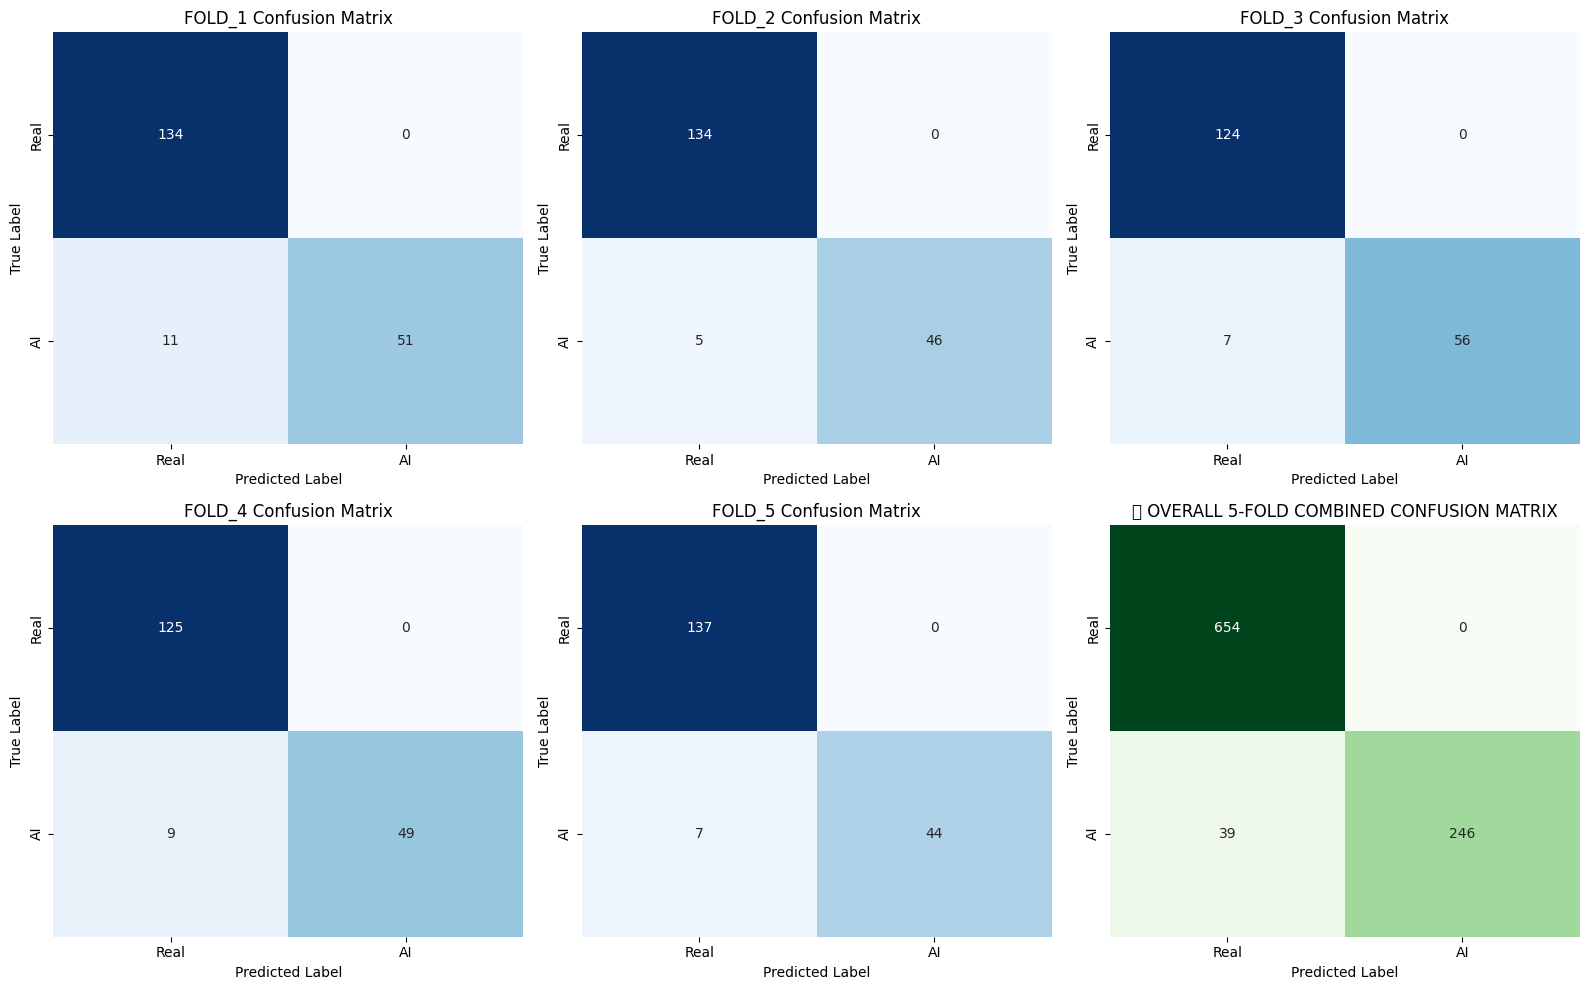


📋 OVERALL OUT-OF-FOLD CLASSIFICATION REPORT (100% DATASET, VIDEO-LEVEL)
              precision    recall  f1-score   support

        Real     0.9437    1.0000    0.9710       654
          AI     1.0000    0.8632    0.9266       285

    accuracy                         0.9585       939
   macro avg     0.9719    0.9316    0.9488       939
weighted avg     0.9608    0.9585    0.9575       939



In [18]:
df_kfold = pd.DataFrame(fold_results)

mean_acc = df_kfold["Accuracy"].mean() * 100
std_acc = df_kfold["Accuracy"].std() * 100
mean_f1 = df_kfold["Macro_F1"].mean() * 100
std_f1 = df_kfold["Macro_F1"].std() * 100
mean_prec = df_kfold["Precision"].mean() * 100
std_prec = df_kfold["Precision"].std() * 100
mean_rec = df_kfold["Recall"].mean() * 100
std_rec = df_kfold["Recall"].std() * 100

print("===============================================================")
print("📊 5-FOLD STRATIFIED GROUPKFOLD CROSS-VALIDATION SUMMARY (ViT)")
print("===============================================================")
display(df_kfold)

print("\n--- 📈 OVERALL 5-FOLD CROSS-VALIDATION RESULTS (MEAN ± STD) ---")
print(f"Accuracy:         {mean_acc:.2f}% ± {std_acc:.2f}%")
print(f"Precision (Macro): {mean_prec:.2f}% ± {std_prec:.2f}%")
print(f"Recall (Macro):    {mean_rec:.2f}% ± {std_rec:.2f}%")
print(f"Macro F1-Score:   {mean_f1:.2f}% ± {std_f1:.2f}%")

# --------------------------------------------------------
# 🧩 Plot Confusion Matrices Across All 5 Folds & Aggregated
# --------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

all_targets_combined = []
all_preds_combined = []

for fold_idx, (fold_name, res) in enumerate(oof_predictions.items()):
    y_true = res["targets"]
    y_pred = res["preds"]
    all_targets_combined.extend(y_true)
    all_preds_combined.extend(y_pred)
    
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[fold_idx],
                xticklabels=CLASSES, yticklabels=CLASSES)
    axes[fold_idx].set_title(f"{fold_name.upper()} Confusion Matrix")
    axes[fold_idx].set_xlabel("Predicted Label")
    axes[fold_idx].set_ylabel("True Label")

# Plot Overall Combined Out-of-Fold Confusion Matrix
cm_overall = confusion_matrix(all_targets_combined, all_preds_combined, labels=[0, 1])
sns.heatmap(cm_overall, annot=True, fmt="d", cmap="Greens", cbar=False, ax=axes[5],
            xticklabels=CLASSES, yticklabels=CLASSES)
axes[5].set_title("🏆 OVERALL 5-FOLD COMBINED CONFUSION MATRIX")
axes[5].set_xlabel("Predicted Label")
axes[5].set_ylabel("True Label")

plt.tight_layout()
plt.show()

print("\n===============================================================")
print("📋 OVERALL OUT-OF-FOLD CLASSIFICATION REPORT (100% DATASET, VIDEO-LEVEL)")
print("===============================================================")
print(classification_report(all_targets_combined, all_preds_combined, target_names=CLASSES, digits=4))


## 9. Single Video 5-Fold Ensemble Inference Helper

In [19]:
def predict_video_kfold_ensemble(video_path, target_fps=1.0, max_frames=30):
    """
    Ensemble inference across all 5 fine-tuned fold models for maximum generalization.
    """
    frames = extract_frames(video_path, "/content/temp_infer_frames", target_fps=target_fps, max_frames=max_frames)
    frame_paths = glob.glob("/content/temp_infer_frames/*.jpg")
    if not frame_paths:
        return "Failed to extract frames", 0.0
    
    tensors = torch.stack([val_transform(Image.open(fp).convert('RGB')) for fp in frame_paths]).to(device)
    fold_probs = []
    
    for fold_name in kfold_splits.keys():
        model_path = os.path.join(MODEL_SAVE_DIR, f"dima806_deepfake_aug_{fold_name}")
        if os.path.exists(model_path):
            m = AutoModelForImageClassification.from_pretrained(model_path).to(device)
            m.eval()
            with torch.no_grad():
                outputs = m(tensors)
                probs = F.softmax(outputs.logits, dim=-1).cpu().numpy()
                fold_probs.append(np.mean(probs, axis=0))
            del m
            torch.cuda.empty_cache()
    
    if not fold_probs:
        return "No fold models found", 0.0
    
    ensemble_prob = np.mean(fold_probs, axis=0)
    pred_idx = int(np.argmax(ensemble_prob))
    pred_label = CLASSES[pred_idx]
    conf = float(ensemble_prob[pred_idx])
    return pred_label, conf

# Example Usage:
# label, conf = predict_video_kfold_ensemble("/content/dataset_raw/AI/sample_video.mp4")

## 10. Independent Held-Out Test Set Evaluation (`testReal.zip` & `testAI.zip`)
### 🧪 Evaluates 5-Fold Ensemble Model on Completely Separate Test Archives

This section unzips the dedicated test archives **`testReal.zip`** and **`testAI.zip`** from Google Drive (`Dataset Indonesia/`), extracts 1 FPS frames, and evaluates the **5-Fold Soft Voting Ensemble** on independent unseen test videos.

⏭️ Target test directory '/content/dataset_raw_test/Real' already exists. Skipping unzip.
⏭️ Target test directory '/content/dataset_raw_test/AI' already exists. Skipping unzip.
🎥 Extracting 1 FPS frames for 190 Real test videos ...


Test Frames [Real]: 100%|██████████| 190/190 [00:00<00:00, 30408.58it/s]


🎥 Extracting 1 FPS frames for 122 AI test videos ...


Test Frames [AI]: 100%|██████████| 122/122 [00:00<00:00, 34131.88it/s]


🧪 EVALUATING 5-FOLD ENSEMBLE ON HELD-OUT TEST SET (312 Videos)


...

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

✅ Active Ensemble Models Loaded: 5 / 5


Ensemble Test Infer: 100%|██████████| 312/312 [02:05<00:00,  2.48it/s]


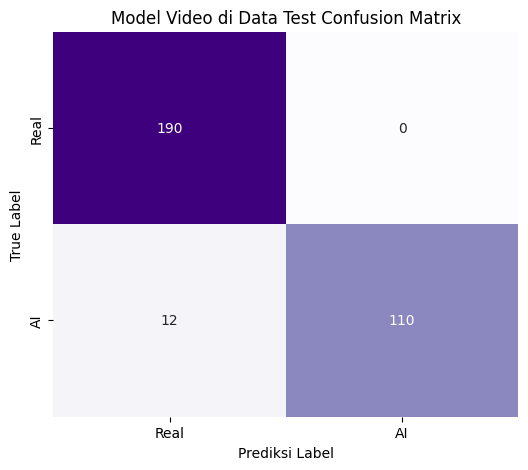


📋 INDEPENDENT HELD-OUT TEST SET CLASSIFICATION REPORT
              precision    recall  f1-score   support

        Real     0.9406    1.0000    0.9694       190
          AI     1.0000    0.9016    0.9483       122

    accuracy                         0.9615       312
   macro avg     0.9703    0.9508    0.9588       312
weighted avg     0.9638    0.9615    0.9611       312



In [20]:
import os
# Independent Test Zip Paths in Google Drive
ZIP_TEST_PATHS = {
    "Real": [
        os.path.join(DRIVE_DATASET_DIR, "Real", "testReal.zip"),
        os.path.join(DRIVE_DATASET_DIR, "testReal.zip")
    ],
    "AI": [
        os.path.join(DRIVE_DATASET_DIR, "AI", "testAI.zip"),
        os.path.join(DRIVE_DATASET_DIR, "testAI.zip")
    ]
}

LOCAL_RAW_TEST_DIR = "/content/dataset_raw_test"
LOCAL_FRAMES_TEST_DIR = "/content/dataset_frames_test"
os.makedirs(LOCAL_RAW_TEST_DIR, exist_ok=True)
os.makedirs(LOCAL_FRAMES_TEST_DIR, exist_ok=True)

# Unzip Independent Test Archives
for cls in CLASSES:
    extract_target = os.path.join(LOCAL_RAW_TEST_DIR, cls)
    candidates = ZIP_TEST_PATHS.get(cls, [])
    found_zip = None
    for p in candidates:
        if os.path.exists(p):
            found_zip = p
            break
    
    if found_zip:
        if os.path.exists(extract_target) and len(os.listdir(extract_target)) > 0:
            print(f"⏭️ Target test directory '{extract_target}' already exists. Skipping unzip.")
        else:
            unzip_file(found_zip, extract_target)
    else:
        print(f"⚠️ Warning: Could not locate test zip for {cls} at candidates: {candidates}")

# Extract Frames from Test Videos
for cls in CLASSES:
    cls_raw_dir = os.path.join(LOCAL_RAW_TEST_DIR, cls)
    cls_frames_dir = os.path.join(LOCAL_FRAMES_TEST_DIR, cls)
    if not os.path.exists(cls_raw_dir):
        continue
    video_extensions = ("*.mp4", "*.avi", "*.mov", "*.mkv", "*.MP4", "*.AVI", "*.MOV", "*.MKV")
    video_files = []
    for ext in video_extensions:
        video_files.extend(glob.glob(os.path.join(cls_raw_dir, "**", ext), recursive=True))
    
    print(f"🎥 Extracting 1 FPS frames for {len(video_files)} {cls} test videos ...")
    for vid in tqdm(video_files, desc=f"Test Frames [{cls}]"):
        v_stem = Path(vid).stem
        out_v_dir = os.path.join(cls_frames_dir, v_stem)
        if os.path.exists(out_v_dir) and len(os.listdir(out_v_dir)) > 0:
            continue
        n_frames = extract_frames(vid, out_v_dir, target_fps=1.0, max_frames=30)
        if n_frames == 0:
            # OpenCV failed to decode (e.g. VP9/AV1/H.265) -> ffmpeg fallback
            n_frames = extract_frames_ffmpeg(vid, out_v_dir, target_fps=1.0, max_frames=30)
        if n_frames == 0:
            print(f"⚠️ WARNING: Could not extract any frames from test video: {vid}")

# Evaluate 5-Fold Soft Voting Ensemble on Independent Test Set
test_video_samples = []
for label_idx, cls in enumerate(CLASSES):
    cls_dir = os.path.join(LOCAL_FRAMES_TEST_DIR, cls)
    if not os.path.exists(cls_dir):
        continue
    v_folders = [os.path.join(cls_dir, d) for d in os.listdir(cls_dir) if os.path.isdir(os.path.join(cls_dir, d))]
    for vf in v_folders:
        frames = glob.glob(os.path.join(vf, "*.jpg"))
        if frames:
            test_video_samples.append((vf, frames, label_idx, Path(vf).name))

eval_stems = {Path(vf).name for vf, _, _, _ in test_video_samples}
raw_test_stems = set()
for cls in CLASSES:
    cls_dir = os.path.join(LOCAL_RAW_TEST_DIR, cls)
    if not os.path.exists(cls_dir):
        continue
    for ext in ("*.mp4", "*.avi", "*.mov", "*.mkv", "*.MP4", "*.AVI", "*.MOV", "*.MKV"):
        raw_test_stems.update(Path(vf).stem for vf in glob.glob(os.path.join(cls_dir, "**", ext), recursive=True))
dropped_stems = sorted(raw_test_stems - eval_stems)
if dropped_stems:
    print(f"⚠️ WARNING: {len(dropped_stems)} test videos produced 0 frames and were EXCLUDED from evaluation: {dropped_stems[:20]}{'...' if len(dropped_stems) > 20 else ''}")

print(f"\n===============================================================")
print(f"🧪 EVALUATING 5-FOLD ENSEMBLE ON HELD-OUT TEST SET ({len(test_video_samples)} Videos)")
print(f"===============================================================")

# Load all 5 fold models for ensemble inference
ensemble_models = []
for fold_name in kfold_splits.keys():
    m_path = os.path.join(MODEL_SAVE_DIR, f"dima806_deepfake_aug_{fold_name}")
    if os.path.exists(m_path):
        m = AutoModelForImageClassification.from_pretrained(m_path).to(device)
        m.eval()
        ensemble_models.append(m)

print(f"✅ Active Ensemble Models Loaded: {len(ensemble_models)} / {len(kfold_splits)}")

y_true_test = []
y_pred_test = []
video_confidences = []

if len(ensemble_models) > 0 and len(test_video_samples) > 0:
    for vf, frames, true_label, v_stem in tqdm(test_video_samples, desc="Ensemble Test Infer"):
        tensors = torch.stack([val_transform(Image.open(fp).convert('RGB')) for fp in frames]).to(device)
        fold_probs = []
        with torch.no_grad():
            for m in ensemble_models:
                with torch.amp.autocast("cuda"):
                    outputs = m(tensors)
                    probs = F.softmax(outputs.logits if hasattr(outputs, 'logits') else outputs, dim=-1).cpu().numpy()
                fold_probs.append(np.mean(probs, axis=0))
        
        ens_prob = np.mean(fold_probs, axis=0)
        pred_lbl = int(np.argmax(ens_prob))
        y_true_test.append(true_label)
        y_pred_test.append(pred_lbl)
        video_confidences.append(float(ens_prob[pred_lbl]))
    
    # Plot Independent Test Set Confusion Matrix
    fig, ax = plt.subplots(figsize=(6, 5))
    cm_test = confusion_matrix(y_true_test, y_pred_test, labels=[0, 1])
    sns.heatmap(cm_test, annot=True, fmt="d", cmap="Purples", cbar=False, ax=ax,
                xticklabels=CLASSES, yticklabels=CLASSES)
    ax.set_title("Model Video di Data Test Confusion Matrix")
    ax.set_xlabel("Prediksi Label")
    ax.set_ylabel("True Label")
    plt.show()
    
    print("\n===============================================================")
    print("📋 INDEPENDENT HELD-OUT TEST SET CLASSIFICATION REPORT")
    print("===============================================================")
    print(classification_report(y_true_test, y_pred_test, target_names=CLASSES, digits=4))
else:
    print("ℹ️ Test video samples or fine-tuned fold checkpoints not ready for test evaluation.")
